In [ ]:
%load_ext autoreload
%autoreload 2

# Library/module imports
from matplotlib import pyplot as plt
import numpy as np
from dataclasses import asdict

from polarity.models import par3nd as pmodel
from polarity.utilities import figure_helper as fh
from polarity.utilities.metric_functions import polarity_measure, find_interface

## Example of establishment using default parameters (Fig. 5)

In [2]:
# Discretisation and initial conditions
initial_condition = pmodel.run_for_ss_initial_condition()
Nx = len(initial_condition) // 4
print(f"Initial condition: [J, M, A, P] = {initial_condition[[0, Nx, 2*Nx, 3*Nx]]}")

# Timings
tL = 120*60
output_freq = 10 # seconds (affects smoothness of the polarity and interface plots, but not the J/M/A/P plots)
store_times = np.linspace(0,tL,num = int(tL/output_freq)+1)

# Run to steady state (~15-20 seconds)
sol, setup = pmodel.run_model({
                        "t_eval": store_times,
                        "tL": tL, 
                        "initial_condition": initial_condition
                    })

Initial condition: [J, M, A, P] = [0.96207572 1.08219844 0.18930604 0.01458896]


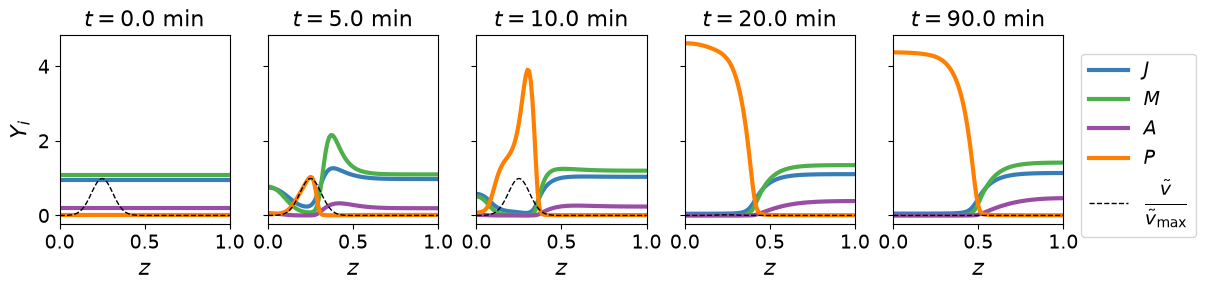

In [5]:
# Plot the profiles over time
plot_times = [mins*60 for mins in [0, 5, 10, 20, 90]]
fig, axs = plt.subplots(nrows=1, ncols=len(plot_times), 
                        sharey=True, layout='constrained', figsize=(fh.page_width_fig, 2.8))
for i, time in enumerate(plot_times):
    ti = [i for i, t in enumerate(store_times) if t == time]
    assert len(ti) == 1, f"Time {time} not found in store_times"
    ax = axs[i]
    fh.plot_time_point(ax, setup.X, sol.y[:, ti[0]], v_func = lambda x: setup.v_func(setup, x, time))
    ax.set_title(f"$t={time/60}$ min", fontsize=fh.font_size)
    if i != 0:
        ax.set_ylabel(None)
fh.add_shared_legend(fig, axs)
fig.savefig(fh.FIGURES_DIR / "establishment_example.pdf", bbox_inches='tight')

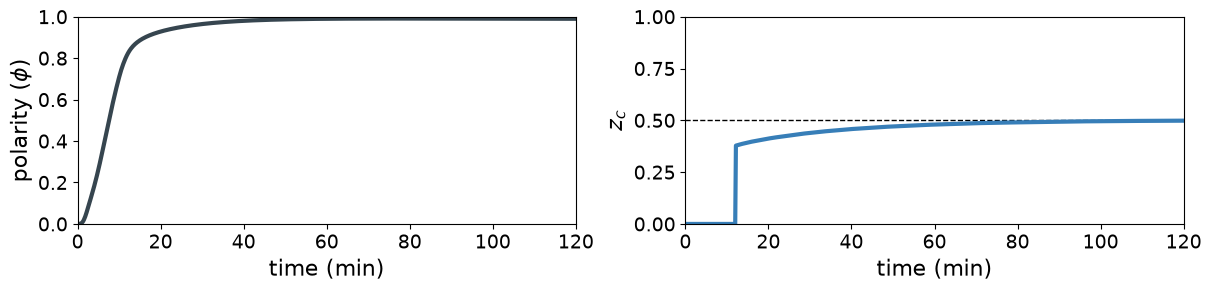

In [6]:
# Plot polarity and interface over time - Fig. 5b
fig, axs = plt.subplots(nrows=1, ncols=2, sharey=False, layout='constrained', figsize=(fh.page_width_fig, 2.8))

# Polarity measure
polarity = [polarity_measure(setup.X, sol.y[:, ti], setup.Species) for ti in range(np.shape(sol.y)[1])]
axs[0].plot(sol.t/60, polarity, color = fh.colours_map["polarity"])
axs[0].set_ylabel("polarity ($\\phi$)")
axs[0].set_xlabel("time (min)")
axs[0].tick_params(which="both")
axs[0].set_ylim(0,1)

# Apical-Basal Interface
interface = [find_interface(setup.X, sol.y[:, ti], setup.Species) for ti in range(np.shape(sol.y)[1])]
axs[1].axhline(y=0.5, color='k', linestyle='--', linewidth = 1)
axs[1].plot(sol.t/60, interface, color = fh.colours_map["J"])
axs[1].set_ylabel("$z_c$")
axs[1].set_xlabel("time (min)")
axs[1].set_ylim(0,1)
_ = axs[1].set_yticks([0, 0.25, 0.5, 0.75, 1])

fig.savefig(fh.FIGURES_DIR / "establishment_example_polarity.pdf", bbox_inches='tight')


MovieWriter ffmpeg unavailable; using Pillow instead.


Saving animation to /Users/cmil633/Documents/Active-Projects/Cell-Polarity/daniel_repo/figures/establishment_example_animation.gif


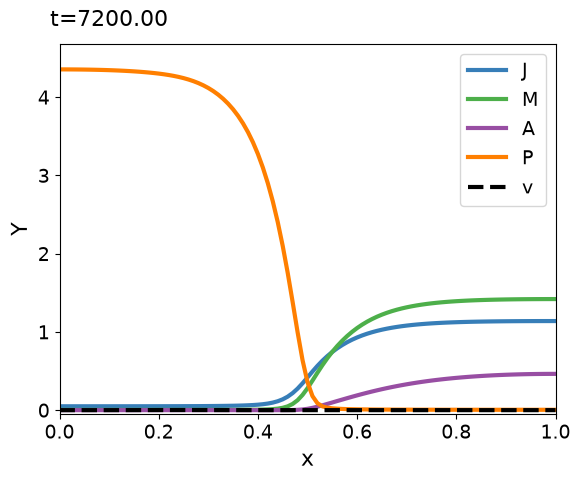

In [ ]:
# Save an animation of the profiles over time
fh.animate_plot(sol, asdict(setup), save_file = fh.FIGURES_DIR / "establishment_example_animation")

## Polarisation metric examples (Fig. 3)

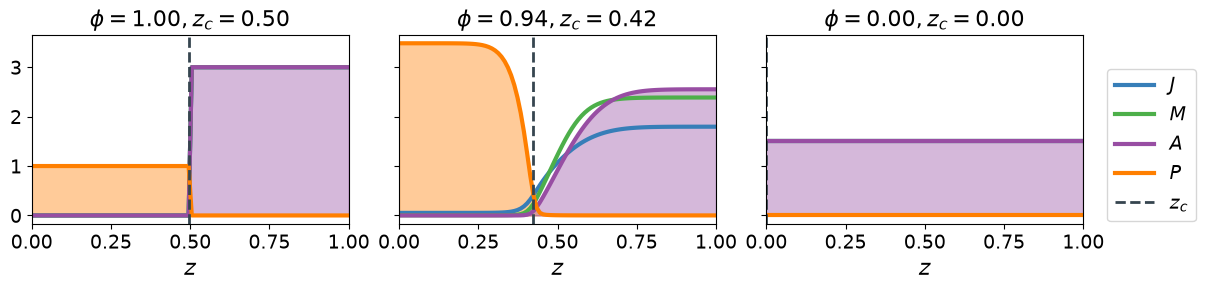

In [8]:
# Plot three example profiles
# Solve for the 'realistic' example
Nx = 100
hw = 50 # Half width of the domain
initial_condition = [0]*(hw) + [3]*(hw) +  [0]*(hw) + [3]*(hw) + [0]*(hw) + [3]*(hw) + [1]*(hw) + [0]*(hw)
tL = 120
sol_eg,setup_eg = pmodel.run_model({"Nx": Nx,
                          "t_eval": [0,tL],
                          "tL": tL, 
                          "initial_condition": initial_condition,
                          "v_func": pmodel.zero_v_func
                          })
polarity_zero_col = [1.5]*(3*Nx) + [0]*(Nx)

# Stack solutions and plot: initial condition, realistic example, and zero polarity example
sol_eg.y = np.column_stack((sol_eg.y, polarity_zero_col))
fig, axs = plt.subplots(nrows=1, ncols=3, 
                        sharey=True, layout='constrained', figsize=(fh.page_width_fig, 2.8))
for i in range(3):
    ax = axs[i]
    df = fh.convert_output_to_pandas(setup_eg.X, sol_eg.y[:, i])
    ax.fill_between(df.x, df.P, color=fh.colours_map["P"], alpha=0.4)
    ax.fill_between(df.x, df.A, color=fh.colours_map["A"], alpha=0.4)
    fh.plot_time_point(ax, setup_eg.X, sol_eg.y[:, i])
    
    polarity = polarity_measure(setup_eg.X, sol_eg.y[:, i], setup_eg.Species)
    interface = find_interface(setup_eg.X, sol_eg.y[:, i], setup_eg.Species)
    ax.axvline(interface, linestyle="--", color=fh.colours_map["polarity"], linewidth=2, label = "$z_c$")
    ax.set_title(f"$\\phi={polarity:.2f}, z_c = {interface:.2f}$", fontsize=fh.font_size)
    
    ax.set_ylabel(None)
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
fh.add_shared_legend(fig, axs)

fig.savefig(fh.FIGURES_DIR / "metrics_diagram.pdf", bbox_inches='tight')
